# ЛР №2. Сетевая задача и дискретная оптимизация
Вариант 1

## Часть 1. Максимальный поток и минимальный разрез

In [1]:
from itertools import combinations


def find_vertices(edges, start):
    """Список узлов и сток (узел, из которого не выходит ни одной дуги)."""
    vertices = [start]
    for edge in edges:
        for v in edge:
            if v not in vertices:
                vertices.append(v)

    sink = None
    for v in vertices:
        has_outgoing = False
        for edge in edges:
            if edge[0] == v:
                has_outgoing = True
        if not has_outgoing:
            sink = v
    return vertices, sink


def max_flow(edges, weights, start):
    """Перебор всех разрезов (S, T), отделяющих s от t: максимальный поток равен минимальному разрезу."""
    vertices, sink = find_vertices(edges, start)

    others = []
    for v in vertices:
        if v != start and v != sink:
            others.append(v)

    best = None
    best_S = []
    all_cuts = []
    for k in range(len(others) + 1):
        for comb in combinations(others, k):
            S = [start] + list(comb)

            cut = 0
            for i in range(len(edges)):
                u = edges[i][0]
                v = edges[i][1]
                if u in S and v not in S:
                    cut += weights[i]
            all_cuts.append((S, cut))

            if best is None or cut < best:
                best = cut
                best_S = [S]
            elif cut == best:
                best_S.append(S)

    return best, best_S, all_cuts


def ford_fulkerson(edges, weights, start):
    """Алгоритм из лекции: увеличивающие пути в остаточной сети (поиск в ширину)."""
    vertices, sink = find_vertices(edges, start)
    n = len(vertices)
    s = vertices.index(start)
    t = vertices.index(sink)

    # матрица остаточных пропускных способностей
    r = [[0] * n for i in range(n)]
    for i in range(len(edges)):
        r[vertices.index(edges[i][0])][vertices.index(edges[i][1])] = weights[i]

    total = 0
    while True:
        parent = [-1] * n
        parent[s] = s
        queue = [s]
        while len(queue) > 0:
            u = queue.pop(0)
            for v in range(n):
                if r[u][v] > 0 and parent[v] == -1:
                    parent[v] = u
                    queue.append(v)
        if parent[t] == -1:
            break

        path = [t]
        while path[-1] != s:
            path.append(parent[path[-1]])
        path.reverse()

        delta = min(r[path[i]][path[i + 1]] for i in range(len(path) - 1))
        for i in range(len(path) - 1):
            r[path[i]][path[i + 1]] -= delta
            r[path[i + 1]][path[i]] += delta
        total += delta
        print("путь:", [vertices[i] for i in path], "delta =", delta, "поток =", total)

    flow = {}
    for i in range(len(edges)):
        u, v = edges[i]
        flow[(u, v)] = weights[i] - r[vertices.index(u)][vertices.index(v)]
    S = [vertices[i] for i in range(n) if parent[i] != -1]
    return total, flow, S


# связи (дуги), пропускные способности, источник
edges = [("s", "a"), ("s", "b"), ("a", "c"), ("a", "d"),
         ("b", "c"), ("b", "d"), ("c", "t"), ("d", "t")]
weights = [10, 10, 4, 5, 6, 3, 10, 10]
start = "s"

best, best_S, all_cuts = max_flow(edges, weights, start)
for S, cut in all_cuts:
    print("S =", S, "пропускная способность разреза =", cut)
print("Минимальный разрез:", best, best_S)

total, flow, S = ford_fulkerson(edges, weights, start)
print("Максимальный поток:", total)
print("Поток по дугам:", flow)
print("S =", S)

# способ увеличения потока (бутылочное горлышко):
# расширяем каждую дугу по очереди и смотрим прирост потока
for i in range(len(edges)):
    w1 = weights[:]
    w1[i] += 1
    w2 = weights[:]
    w2[i] += 1000
    print(edges[i], "+1:", max_flow(edges, w1, start)[0] - best,
          " +1000:", max_flow(edges, w2, start)[0] - best)

w = weights[:]
w[3] += 1    # дуга (a, d)
w[5] += 1    # дуга (b, d)
print("После расширения (a,d) и (b,d) на 1:", max_flow(edges, w, start)[0])


S = ['s'] пропускная способность разреза = 20
S = ['s', 'a'] пропускная способность разреза = 19
S = ['s', 'b'] пропускная способность разреза = 19
S = ['s', 'c'] пропускная способность разреза = 30
S = ['s', 'd'] пропускная способность разреза = 30
S = ['s', 'a', 'b'] пропускная способность разреза = 18
S = ['s', 'a', 'c'] пропускная способность разреза = 25
S = ['s', 'a', 'd'] пропускная способность разреза = 24
S = ['s', 'b', 'c'] пропускная способность разреза = 23
S = ['s', 'b', 'd'] пропускная способность разреза = 26
S = ['s', 'c', 'd'] пропускная способность разреза = 40
S = ['s', 'a', 'b', 'c'] пропускная способность разреза = 18
S = ['s', 'a', 'b', 'd'] пропускная способность разреза = 20
S = ['s', 'a', 'c', 'd'] пропускная способность разреза = 30
S = ['s', 'b', 'c', 'd'] пропускная способность разреза = 30
S = ['s', 'a', 'b', 'c', 'd'] пропускная способность разреза = 20
Минимальный разрез: 18 [['s', 'a', 'b'], ['s', 'a', 'b', 'c']]
путь: ['s', 'a', 'c', 't'] delta = 4 пото

## Часть 2. Числа Фибоначчи

In [2]:
import matplotlib.pyplot as plt
import time
import sys

sys.setrecursionlimit(10000)


In [3]:
# 1) Рекурсия
def fubanachi0(n):
    if n < 2:
        return n
    return fubanachi0(n - 1) + fubanachi0(n - 2)

print(fubanachi0(8))


21


In [4]:
# 2) Мемоизация (кеширование)
cache = {}

def fubanachi1(n):
    if n in cache:
        return cache[n]
    if n < 2:
        result = n
    else:
        result = fubanachi1(n - 1) + fubanachi1(n - 2)
    cache[n] = result
    return result

print(fubanachi1(8))


21


In [5]:
# 3) Динамическое программирование:
# для вычисления k-го числа запоминаем (k-1)-е и (k-2)-е числа
def fubanachi2(n):
    a, b = 0, 1
    for _ in range(n):
        a, b = b, a + b
    return a

print(fubanachi2(8))


21


In [6]:
print(fubanachi0(30), fubanachi1(30), fubanachi2(30))


832040 832040 832040


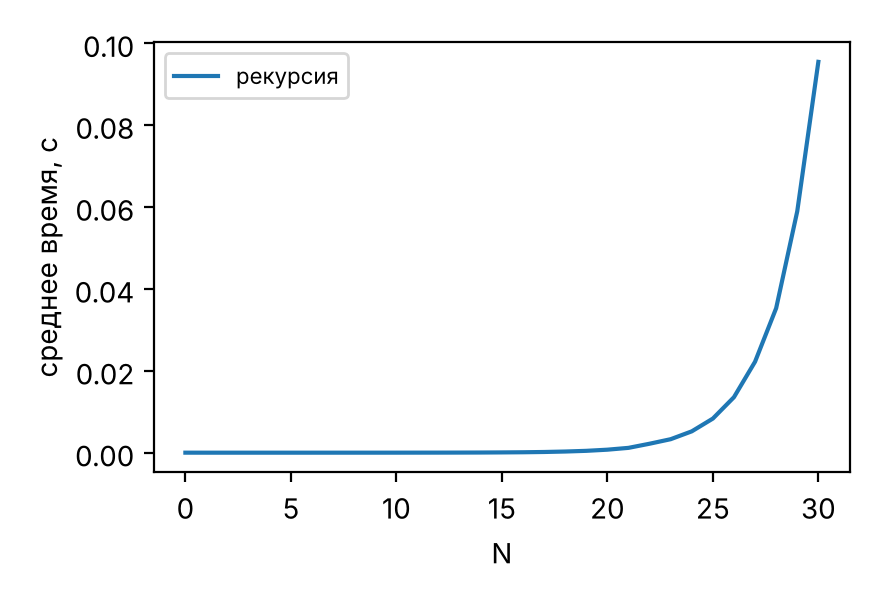

In [7]:
# Рекурсия: среднее время вычисления N-го числа по repeat0 запускам.
# Запуски идут проходами по всем N, чтобы случайный скачок нагрузки
# не попадал целиком в одну точку графика.
repeat0 = 30
x0 = range(31)
sum0 = [0] * len(x0)

for r in range(repeat0):
    for k in range(len(x0)):
        start = time.perf_counter()
        fubanachi0(x0[k])
        sum0[k] += time.perf_counter() - start

time0 = [s / repeat0 for s in sum0]

plt.figure(figsize=(4.4, 3.0))
plt.plot(x0, time0, label="рекурсия")
plt.xlabel("N")
plt.ylabel("среднее время, с")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


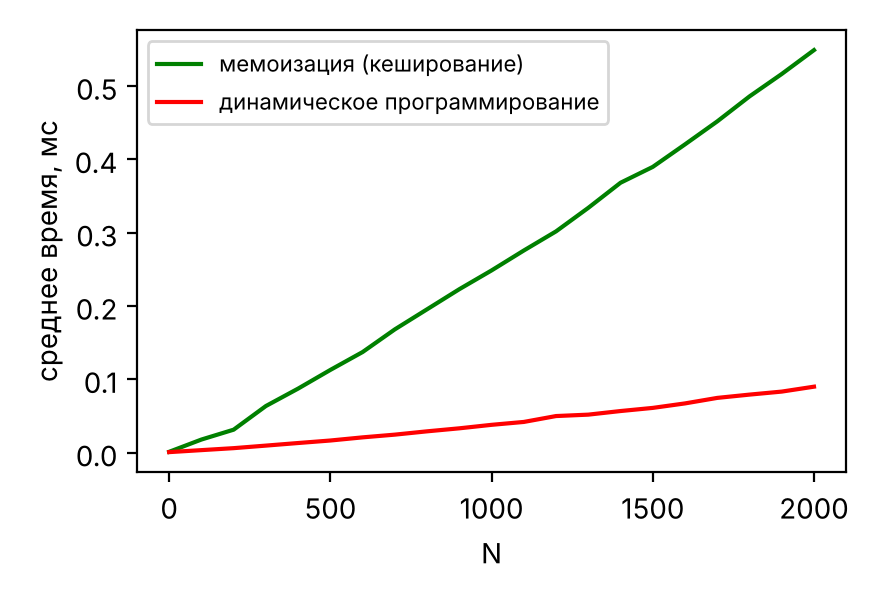

In [8]:
# Мемоизация и динамическое программирование:
# среднее время вычисления N-го числа по repeat запускам;
# эти два метода строим отдельно от рекурсии, на одном графике, чтобы сравнить
repeat = 3000
x = range(0, 2001, 100)
sum1 = [0] * len(x)
sum2 = [0] * len(x)

for r in range(repeat):
    for k in range(len(x)):
        cache.clear()
        start = time.perf_counter()
        fubanachi1(x[k])
        sum1[k] += time.perf_counter() - start

        start = time.perf_counter()
        fubanachi2(x[k])
        sum2[k] += time.perf_counter() - start

time1 = [s / repeat for s in sum1]
time2 = [s / repeat for s in sum2]

plt.figure(figsize=(4.4, 3.0))
plt.plot(x, [t * 1000 for t in time1], color='green', label="мемоизация (кеширование)")
plt.plot(x, [t * 1000 for t in time2], color='red', label="динамическое программирование")
plt.xlabel("N")
plt.ylabel("среднее время, мс")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Часть 3. Задача о рюкзаке
Жадный алгоритм

In [9]:
# Жадный алгоритм
B = 50          # вместимость
# (ценность p, вес a) для предметов j = 1..6
pa = [(60, 10), (100, 20), (120, 30), (70, 25), (55, 22), (90, 35)]

items = []
for j in range(len(pa)):
    p, a = pa[j]
    items.append((p / a, p, a, j + 1))

items = sorted(items, reverse=True)

weight = 0
value = 0
taken = []
for c, p, a, j in items:
    print("предмет", j, "p/a =", round(c, 2))
    if weight + a <= B:
        weight += a
        value += p
        taken.append(j)

print("вес:", weight, "ценность:", value, "предметы:", sorted(taken))


предмет 1 p/a = 6.0
предмет 2 p/a = 5.0
предмет 3 p/a = 4.0
предмет 4 p/a = 2.8
предмет 6 p/a = 2.57
предмет 5 p/a = 2.5
вес: 30 ценность: 160 предметы: [1, 2]


Динамическое программирование

In [10]:
# Динамическое программирование
B = 50                           # вместимость
a = [10, 20, 30, 25, 22, 35]     # вес
p = [60, 100, 120, 70, 55, 90]   # ценность

table = [[0] * (B + 1)]

for i in range(len(a)):
    prev = table[-1]
    row = []
    for w in range(B + 1):
        not_take = prev[w]
        take = 0
        if a[i] <= w:
            take = prev[w - a[i]] + p[i]
        row.append(max(not_take, take))
    table.append(row)

for row in table:
    print(row[::10])          # столбцы w = 0, 10, 20, 30, 40, 50

print("ценность:", table[-1][-1])

# какие предметы взяты: идём по таблице снизу вверх
taken = []
w = B
for i in range(len(a), 0, -1):
    if table[i][w] != table[i - 1][w]:
        taken.append(i)
        w -= a[i - 1]

print("предметы:", sorted(taken), "вес:", B - w)


[0, 0, 0, 0, 0, 0]
[0, 60, 60, 60, 60, 60]
[0, 60, 100, 160, 160, 160]
[0, 60, 100, 160, 180, 220]
[0, 60, 100, 160, 180, 220]
[0, 60, 100, 160, 180, 220]
[0, 60, 100, 160, 180, 220]
ценность: 220
предметы: [2, 3] вес: 50
